<a href="https://colab.research.google.com/github/singhshahrahul/AI-ML/blob/main/10_TL_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tools


In [1]:
import tensorflow as tf
import keras
import tensorflow_hub as hub
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

In [2]:
#Get helper_functions.py
!wget https://raw.githubusercontent.com/singhshahrahul/AI-ML/refs/heads/main/helper_function.py

#import helpoer functions
from helper_function import plot_loss_curves, unzip_data, walk_through_dir

--2026-08-23 15:18:16--  https://raw.githubusercontent.com/singhshahrahul/AI-ML/refs/heads/main/helper_function.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11757 (11K) [text/plain]
Saving to: ‘helper_function.py’

helper_function.py  100%[===================>]  11.48K  --.-KB/s    in 0s      

2026-08-23 15:18:16 (26.3 MB/s) - ‘helper_function.py’ saved [11757/11757]



In [3]:
#Get 10% fo the data
!wget  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

unzip_data("10_food_classes_10_percent.zip")

--2026-08-23 15:19:44--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.117.207, 142.250.99.207, 173.194.202.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.117.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   165MB/s    in 1.0s    

2026-08-23 15:19:45 (165 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [4]:
#walk through 10 percent data directory
walk_through_dir("10_food_classes_10_percent")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/test'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/steak'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/sushi'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/fried_rice'.
There are 0 directories and 250 images in '10_food_classes_10_percent/tes

# Work flow

In [5]:
# Load dataset
train_dir = "10_food_classes_10_percent/train"
test_dir = "10_food_classes_10_percent/test"

image_size = (224, 224)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, label_mode="categorical",
    image_size=image_size,
    batch_size=batch_size
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, label_mode="categorical",
    image_size=image_size,
    batch_size=batch_size
)

num_classes = len(train_data.class_names)

#Prefetch for performance
train_data = train_data.prefetch(buffer_size=tf.data.AUTOTUNE)
test_data = test_data.prefetch(buffer_size=tf.data.AUTOTUNE)

#Data augmentation
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
], name = "Data_augmentation")

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [6]:
#Create modle function
def create_model(model_class, preprocess_fn, num_classes, input_shape=(224, 224, 3), data_aug=None):
  base_model = model_class(
      include_top = False,
      weights="imagenet",
      input_shape=input_shape,
      pooling = "avg"
  )

  base_model.trainable = False #For feature extraction first

  inputs = tf.keras.Input(shape=input_shape, name = "input_image")
  x = inputs
  if data_aug:
    x = data_aug(x)
  x = preprocess_fn(x)
  x = base_model(x, training=False)
  outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output_layer")(x)

  model = tf.keras.Model(inputs, outputs, name=model_class.__name__)
  return model

#ResNet

In [7]:
#Create model
model = create_model(ResNet50V2, resnet_preprocess, num_classes, data_aug=data_aug)

#Compile
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

#Train (feature extraction)
history_fe = model.fit(
    train_data, epochs = 5,
    validation_data=test_data
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 580ms/step - accuracy: 0.2800 - loss: 2.1137 - val_accuracy: 0.5972 - val_loss: 1.3059
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 555ms/step - accuracy: 0.5627 - loss: 1.3426 - val_accuracy: 0.6944 - val_loss: 0.9644
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 553ms/step - accuracy: 0.6640 - loss: 1.0275 - val_accuracy: 0.7320 - val_loss: 0.8244
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 553ms/step - accuracy: 0.7427 - loss: 0.8650 - val_accuracy: 0.7592 - val_loss: 0.7370
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 468ms/step - accuracy: 0.7360 - loss: 0.7817 - val_accuracy: 0.7672 - val_loss: 0.7182


In [8]:
model.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.7672 - loss: 0.7182


[0.7182300090789795, 0.7671999931335449]

In [9]:
# Fine-Tuning

#Unfreeze the base model
base_model = model.get_layer("resnet50v2")
base_model.trainable = True

#Optionally freeze first N layers(eg. freeze 100 layers)
for layer in base_model.layers[:100]:
  layer.trainable = False

#Recompile with lower learning rate
model.compile(loss = "categorical_crossentropy",
              optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics = ["accuracy"])

#Train (fine-tuning phase)
history_ft = model.fit(
    train_data,
    validation_data= test_data,
    epochs=5
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 37s 707ms/step - accuracy: 0.6080 - loss: 1.2283 - val_accuracy: 0.7728 - val_loss: 0.7125
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 582ms/step - accuracy: 0.6627 - loss: 1.1172 - val_accuracy: 0.7656 - val_loss: 0.7181
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 582ms/step - accuracy: 0.7280 - loss: 0.9730 - val_accuracy: 0.7656 - val_loss: 0.7227
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 583ms/step - accuracy: 0.7387 - loss: 0.9026 - val_accuracy: 0.7692 - val_loss: 0.7180
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 670ms/step - accuracy: 0.7720 - loss: 0.8318 - val_accuracy: 0.7688 - val_loss: 0.7129


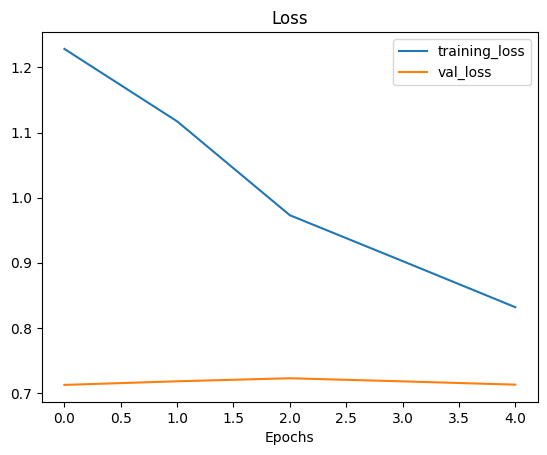

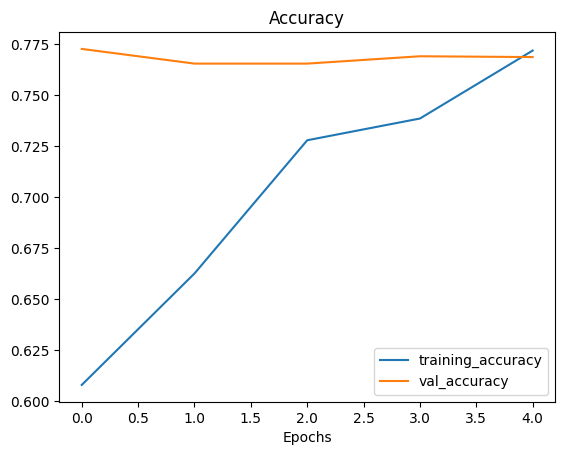

In [10]:
plot_loss_curves(history_ft)

#EfficientNet